In [2]:
# !pip install tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load hourly Bitcoin price data
df_price_btc = pd.read_csv("data/btc1h_usdt.csv", 
                            parse_dates=["open_time"], 
                            index_col=["open_time"])

# Load daily hash rate data
df_hash_rate = pd.read_csv("data/hash_rate.csv", 
                            parse_dates=["date"], 
                            index_col=["date"])

# Check the shape and structure
print(df_price_btc.shape)
print(df_hash_rate.shape)
display(df_price_btc.head())
display(df_hash_rate.head())

# --- Step 1: Aggregate hourly BTC price to daily data ---
df_price_daily = df_price_btc.resample('1D').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
})

# Drop days with missing essential data
df_price_daily.dropna(subset=['open', 'high', 'low', 'close'], inplace=True)

# --- Step 2: Normalize datetime index for both datasets ---
df_price_daily.index = df_price_daily.index.normalize()
df_hash_rate.index = df_hash_rate.index.normalize()

# --- Step 3: Merge price and hash rate on date ---
df_merged = df_price_daily.merge(df_hash_rate, left_index=True, right_index=True, how='inner')

# --- Step 4: Preview merged data ---
display(df_merged.head())


(64730, 111)
(1506, 2)


,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


,timestamp,hash-rate
date,,
2009-01-10,1231545600000,1.065220e-07
2009-01-14,1231891200000,2.521021e-06
2009-01-18,1232236800000,5.588855e-06
2009-01-22,1232582400000,5.681174e-06
2009-01-26,1232928000000,6.270595e-06


,open,high,low,close,volume,timestamp,hash-rate
2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,1503187200000,6.812005e+06
2017-08-24,4147.00,4371.68,4085.01,4316.01,787.418753,1503532800000,6.372733e+06
2017-08-28,4310.01,4399.82,4124.54,4386.69,603.841616,1503878400000,5.293924e+06
2017-09-01,4689.89,4885.55,4654.88,4834.91,560.666366,1504224000000,6.118104e+06
2017-09-05,4106.97,4484.99,3603.00,4366.47,1228.938157,1504569600000,7.234500e+06


In [3]:
!pip install ta

In [4]:
# !pip install ta
import ta

# --- Step 5: Add Technical Indicators ---
df_merged['rsi'] = ta.momentum.RSIIndicator(close=df_merged['close']).rsi()
df_merged['macd'] = ta.trend.MACD(close=df_merged['close']).macd_diff()
df_merged['ema_12'] = ta.trend.EMAIndicator(close=df_merged['close'], window=12).ema_indicator()
df_merged['ema_26'] = ta.trend.EMAIndicator(close=df_merged['close'], window=26).ema_indicator()

# Bollinger Bands
bb = ta.volatility.BollingerBands(close=df_merged['close'])
df_merged['bb_bbm'] = bb.bollinger_mavg()
df_merged['bb_bbh'] = bb.bollinger_hband()
df_merged['bb_bbl'] = bb.bollinger_lband()

# Returns & Volatility
df_merged['daily_return'] = df_merged['close'].pct_change()
df_merged['volatility_7d'] = df_merged['close'].rolling(window=7).std()

# --- Step 6: Clean Data ---
df_merged.dropna(inplace=True)


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Step 7: Select Features for Clustering ---
features = df_merged[[
    'open', 'high', 'low', 'close', 'volume', 'hash-rate',
    'rsi', 'macd', 'ema_12', 'ema_26',
    'bb_bbm', 'bb_bbh', 'bb_bbl',
    'daily_return', 'volatility_7d'
]]

# --- Step 8: Scale + Cluster ---
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled)
df_merged['cluster'] = clusters


\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [6]:
!pip install seaborn

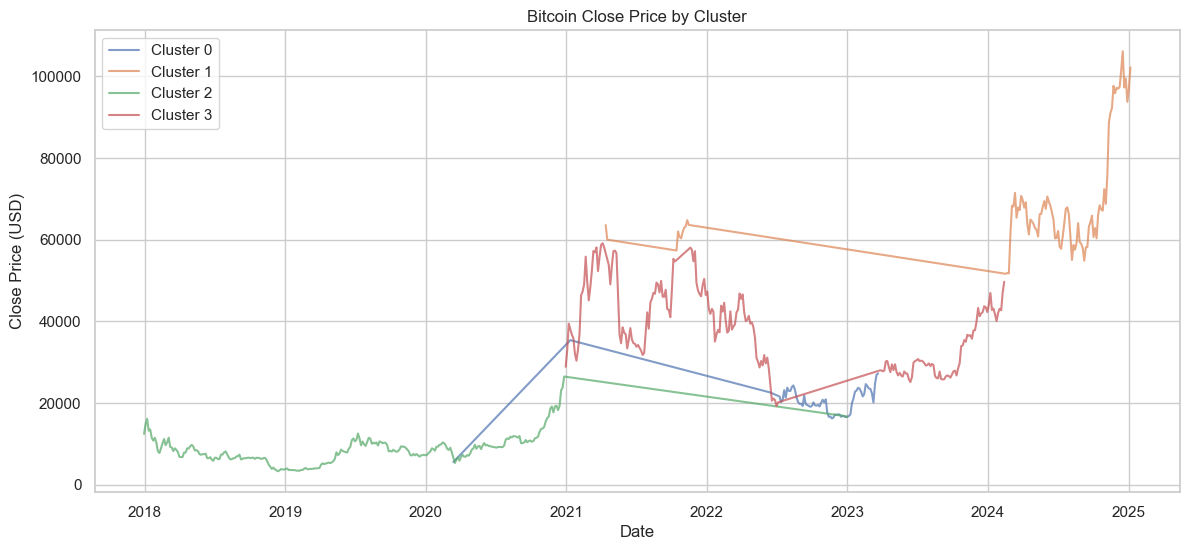

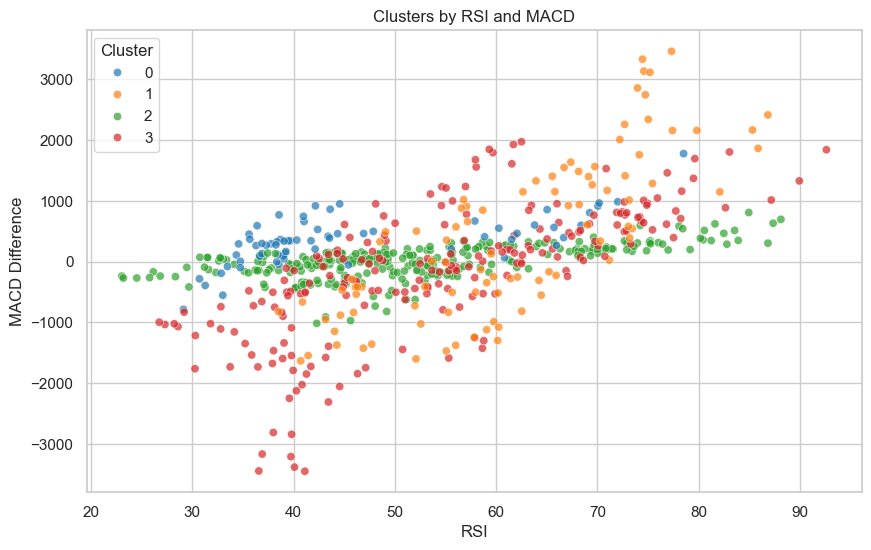

Data points per cluster:
cluster
0     66
1     93
2    275
3    208
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# 1) Plot Bitcoin Close Price colored by Cluster
plt.figure(figsize=(14,6))
for cluster_label in sorted(df_merged['cluster'].unique()):
    cluster_data = df_merged[df_merged['cluster'] == cluster_label]
    plt.plot(cluster_data.index, cluster_data['close'], label=f'Cluster {cluster_label}', alpha=0.7)
plt.title("Bitcoin Close Price by Cluster")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.show()

# 2) Scatter Plot: RSI vs MACD colored by Cluster
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='rsi', y='macd', 
    hue='cluster', 
    palette='tab10', 
    data=df_merged, 
    alpha=0.7
)
plt.title("Clusters by RSI and MACD")
plt.xlabel("RSI")
plt.ylabel("MACD Difference")
plt.legend(title='Cluster')
plt.show()

# 3) Print Cluster Counts
print("Data points per cluster:")
print(df_merged['cluster'].value_counts().sort_index())


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Use past 7 days hash-rate to predict next day hash-rate
N = 7

# Create lag features for hash-rate
for lag in range(1, N+1):
    df_merged[f'hash_rate_lag_{lag}'] = df_merged['hash-rate'].shift(lag)

# Drop NaNs caused by lags
df_model = df_merged.dropna()

# Features = past 7 days hash rate lags
X = df_model[[f'hash_rate_lag_{lag}' for lag in range(1, N+1)]]
y = df_model['hash-rate']

# Split train/test (e.g. last 10% for test)
split_idx = int(len(df_model)*0.9)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on test set: {mse:.4e}")

# Add predictions to dataframe for plotting
df_model = df_model.copy()
df_model.loc[y_test.index, 'hash_rate_pred'] = y_pred



Mean Squared Error on test set: 5.2296e+14


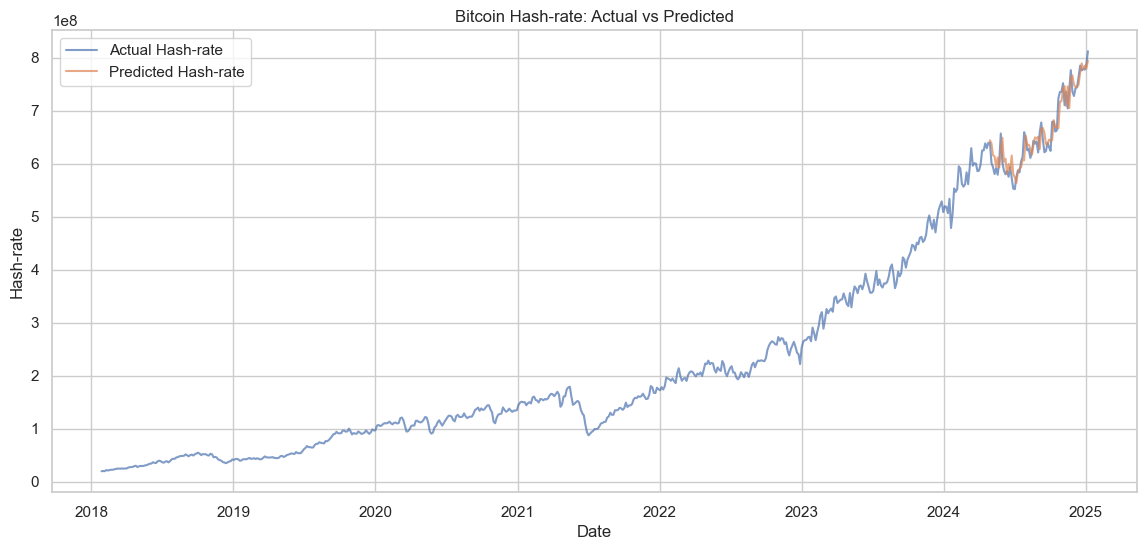

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df_model.index, df_model['hash-rate'], label='Actual Hash-rate', alpha=0.7)
plt.plot(df_model.index, df_model['hash_rate_pred'], label='Predicted Hash-rate', alpha=0.7)
plt.title("Bitcoin Hash-rate: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Hash-rate")
plt.legend()
plt.show()


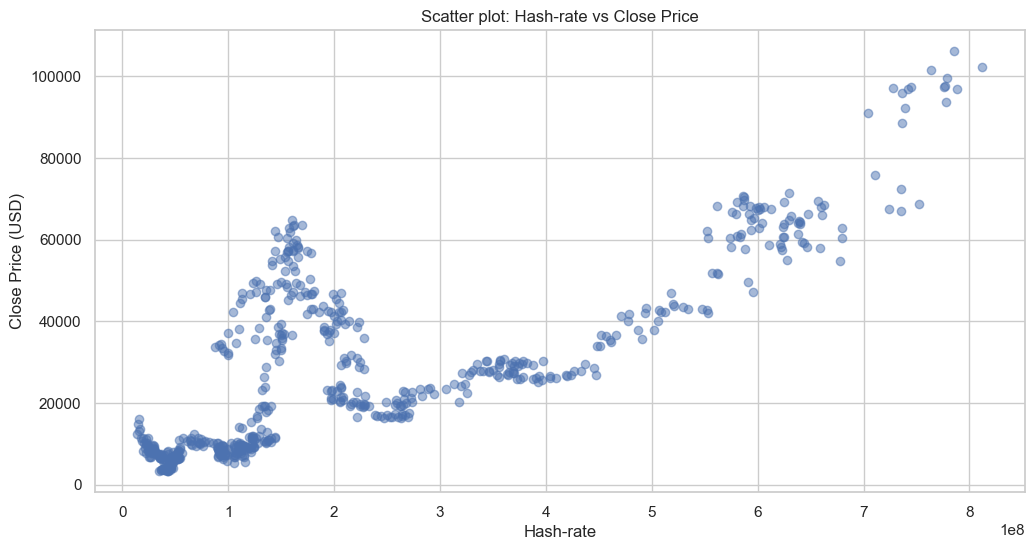

In [10]:
plt.figure(figsize=(12,6))
plt.scatter(df_merged['hash-rate'], df_merged['close'], alpha=0.5)
plt.title("Scatter plot: Hash-rate vs Close Price")
plt.xlabel("Hash-rate")
plt.ylabel("Close Price (USD)")
plt.grid(True)
plt.show()


Mean Squared Error on test set: 5.2296e+14


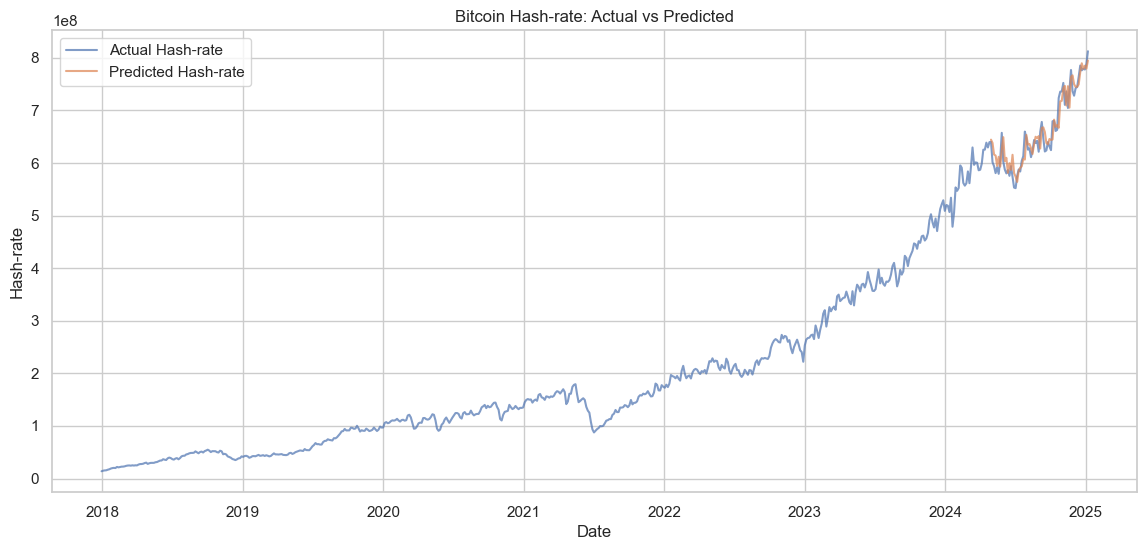

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Use past 7 days hash-rate to predict next day hash-rate
N = 7

# Create lag features for hash-rate
for lag in range(1, N + 1):
    df_merged[f'hash_rate_lag_{lag}'] = df_merged['hash-rate'].shift(lag)

# Drop NaNs caused by lags
df_model = df_merged.dropna().copy()

# Features = past 7 days hash rate lags
X = df_model[[f'hash_rate_lag_{lag}' for lag in range(1, N + 1)]]
y = df_model['hash-rate']

# Split train/test (last 10% for test)
split_idx = int(len(df_model) * 0.9)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on test set: {mse:.4e}")

# Assign predictions back to the full df_merged index, fill with NaNs by default
df_merged['hash_rate_pred'] = np.nan
df_merged.loc[y_test.index, 'hash_rate_pred'] = y_pred

# Plot actual vs predicted hash-rate over entire timeline
plt.figure(figsize=(14, 6))
plt.plot(df_merged.index, df_merged['hash-rate'], label='Actual Hash-rate', alpha=0.7)
plt.plot(df_merged.index, df_merged['hash_rate_pred'], label='Predicted Hash-rate', alpha=0.7)
plt.title("Bitcoin Hash-rate: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Hash-rate")
plt.legend()
plt.show()


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Assume df_merged has columns: ['open', 'high', 'low', 'close', 'volume', 'hash-rate']

# Parameters
features = ['open', 'high', 'low', 'close', 'volume', 'hash-rate']
n_lags = 7
h = 7  # days ahead to predict
target_col = f'target_{h}d'

# Create target column by shifting 'close' price backwards by h days
df_merged[target_col] = df_merged['close'].shift(-h)

# Create lag features
for feat in features:
    for lag in range(1, n_lags + 1):
        df_merged[f'{feat}_lag_{lag}'] = df_merged[feat].shift(lag)

# Drop rows with NaN (due to lagging and shifting)
df_merged.dropna(inplace=True)

# Select lag columns
lag_cols = [f'{feat}_lag_{lag}' for lag in range(1, n_lags + 1) for feat in features]

# Prepare features and target arrays
X_wide = df_merged[lag_cols].values
y = df_merged[target_col].values

# Reshape X for LSTM: (samples, timesteps, features)
n_samples = X_wide.shape[0]
n_features = len(features)
X_3d = X_wide.reshape((n_samples, n_lags, n_features))

# Split data into train/test (no shuffle because time series)
X_train, X_test, y_train, y_test = train_test_split(
    X_3d, y, test_size=0.1, shuffle=False
)

print("Train data shape:", X_train.shape)
print("Test data shape:", X_test.shape)


Train data shape: (51, 7, 6)
Test data shape: (6, 7, 6)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Assuming variables from previous step:
# X_train.shape == (samples, n_lags, n_features)
# y_train.shape == (samples,)

model = Sequential()
model.add(LSTM(64, input_shape=(n_lags, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5010456576.0000
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4911519744.0000
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4933115904.0000
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4831399936.0000
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4906983424.0000
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4904847872.0000
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4873681408.0000
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5011330560.0000
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4991864320.0000
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 4869011456.0000


In [19]:
model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 5021732352.0000
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4895259136.0000
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5025965056.0000
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4997562880.0000
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4923746816.0000
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5017760768.0000
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4877413888.0000
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4935858688.0000
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4877347328.0000
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4976652800.0000


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - loss: 4330957824.0000 - val_loss: 9559555072.0000
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 4383193088.0000 - val_loss: 9559548928.0000
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 4298500096.0000 - val_loss: 9559543808.0000
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 4323618304.0000 - val_loss: 9559535616.0000
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 4321828352.0000 - val_loss: 9559530496.0000
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 4376624128.0000 - val_loss: 9559524352.0000
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 4340438016.0000 - val_loss: 9559518208.0000
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 4399076352.0000 - val_loss: 9559510016.0000
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 4321018880.0000 - val_loss: 9559503872.0000
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 4365853696.0000 - val_loss: 9559

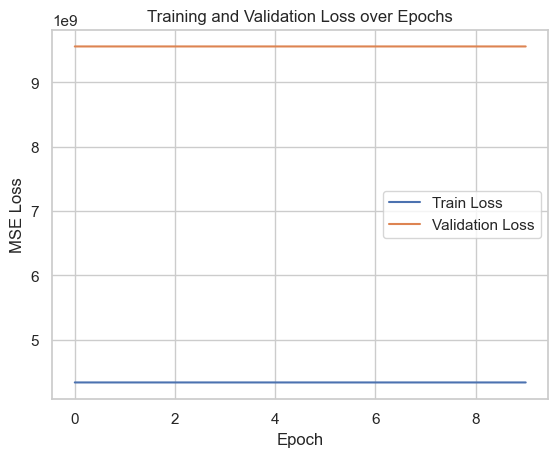

In [20]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


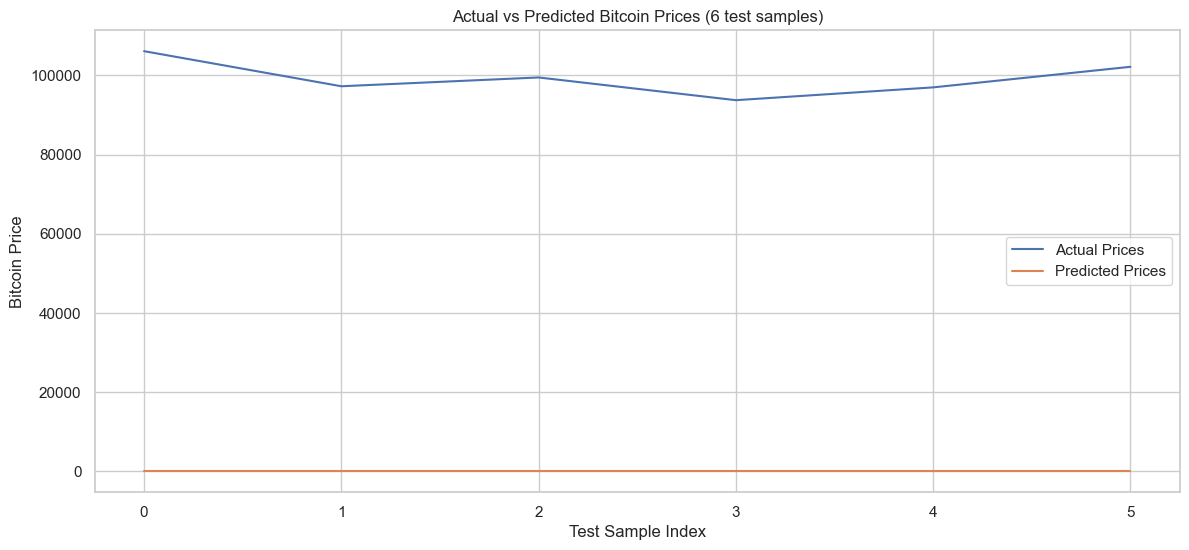

In [21]:
# Predict on test set
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(14,6))
plt.plot(y_test, label='Actual Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.xlabel('Test Sample Index')
plt.ylabel('Bitcoin Price')
plt.title(f'Actual vs Predicted Bitcoin Prices ({len(y_test)} test samples)')
plt.legend()
plt.show()


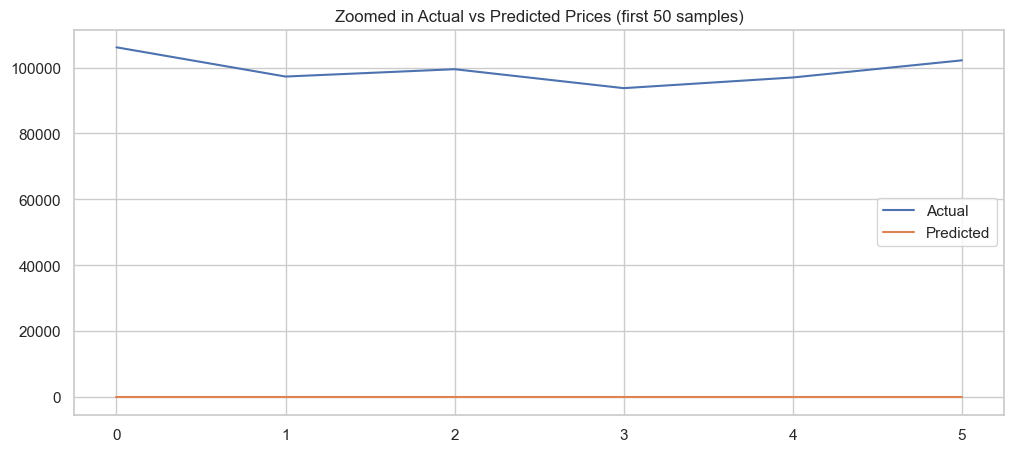

In [22]:
window = 50  # change as you like
plt.figure(figsize=(12,5))
plt.plot(y_test[:window], label='Actual')
plt.plot(y_pred[:window], label='Predicted')
plt.title(f'Zoomed in Actual vs Predicted Prices (first {window} samples)')
plt.legend()
plt.show()


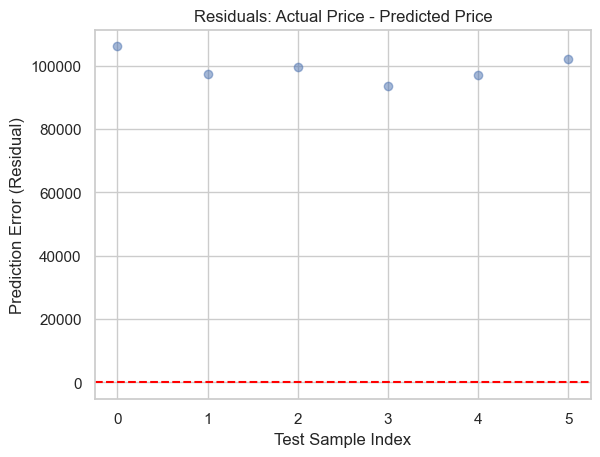

In [23]:
residuals = y_test - y_pred
plt.scatter(range(len(residuals)), residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Test Sample Index')
plt.ylabel('Prediction Error (Residual)')
plt.title('Residuals: Actual Price - Predicted Price')
plt.show()


\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\2415984612.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['cluster'] = clusters


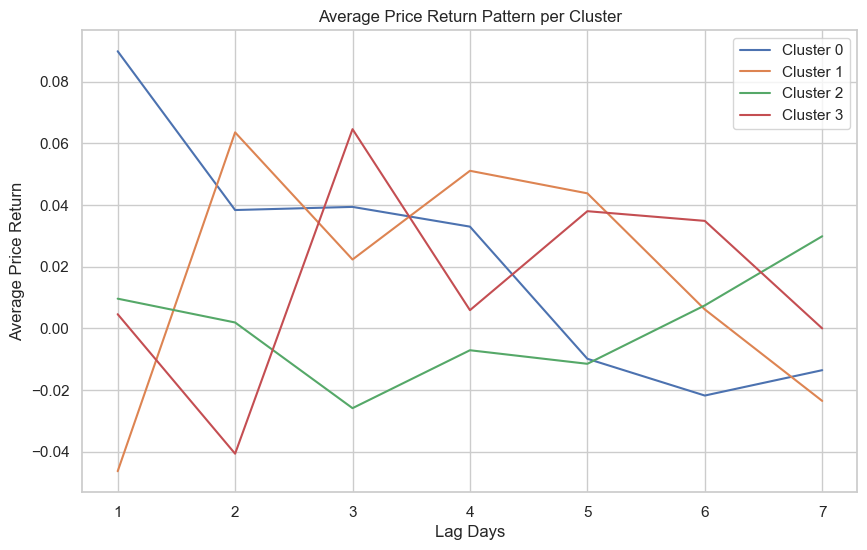

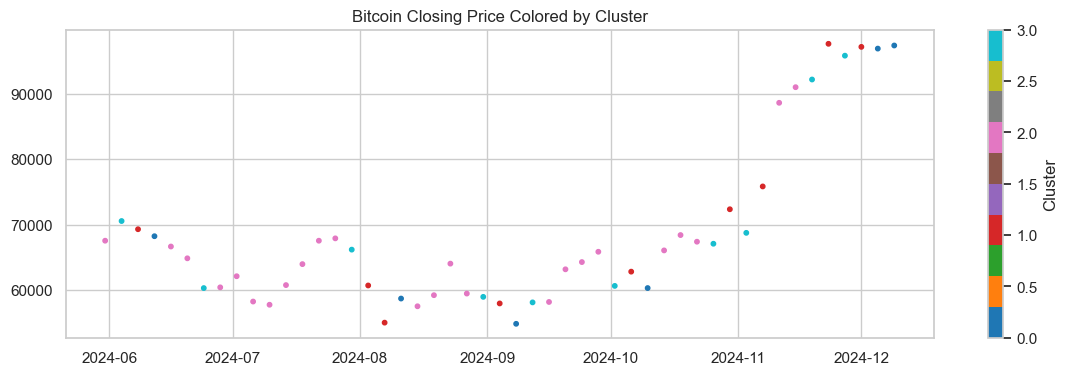

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming df_merged contains daily data with 'close' and 'hash-rate'

# Step 1: Create rolling window features
window = 7

# Compute daily returns for price and hash rate
df_merged['price_return'] = df_merged['close'].pct_change()
df_merged['hashrate_return'] = df_merged['hash-rate'].pct_change()

# Create lagged features for the last 7 days for both returns
features = []
for lag in range(1, window + 1):
    df_merged[f'price_return_lag_{lag}'] = df_merged['price_return'].shift(lag)
    df_merged[f'hashrate_return_lag_{lag}'] = df_merged['hashrate_return'].shift(lag)
    features.extend([f'price_return_lag_{lag}', f'hashrate_return_lag_{lag}'])

df_features = df_merged.dropna(subset=features)  # drop rows with NaNs after shifting

X = df_features[features].values

# Step 2: KMeans clustering
k = 4  # number of clusters/trends
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

df_features['cluster'] = clusters

# Step 3: Visualize average trend per cluster
plt.figure(figsize=(10,6))
for cluster_id in range(k):
    cluster_data = df_features[df_features['cluster'] == cluster_id]
    # average price return lag pattern
    avg_returns = cluster_data[[f'price_return_lag_{i}' for i in range(window, 0, -1)]].mean()
    plt.plot(range(1, window + 1), avg_returns, label=f'Cluster {cluster_id}')
plt.xlabel('Lag Days')
plt.ylabel('Average Price Return')
plt.title('Average Price Return Pattern per Cluster')
plt.legend()
plt.show()

# Step 4: Visualize clusters on timeline
plt.figure(figsize=(14,4))
plt.scatter(df_features.index, df_features['close'], c=df_features['cluster'], cmap='tab10', s=10)
plt.colorbar(label='Cluster')
plt.title('Bitcoin Closing Price Colored by Cluster')
plt.show()


In [25]:
# Calculate average returns for each cluster
cluster_avg_returns = df_features.groupby('cluster')[[f'price_return_lag_{i}' for i in range(1, window+1)]].mean()

# For interpretation, look at mean return over all lags per cluster
cluster_avg = cluster_avg_returns.mean(axis=1)

# Define simple labeling logic
def label_trend(avg_return):
    if avg_return > 0.001:
        return 'Bullish'
    elif avg_return < -0.001:
        return 'Bearish'
    else:
        return 'Sideways'

cluster_labels = cluster_avg.apply(label_trend)
print(cluster_labels)

# Map cluster to label in the DataFrame
df_features['trend_label'] = df_features['cluster'].map(cluster_labels)


cluster
0     Bullish
1     Bullish
2    Sideways
3     Bullish
dtype: object


C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\1649891856.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['trend_label'] = df_features['cluster'].map(cluster_labels)


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create target (next day's cluster)
df_features['target_cluster'] = df_features['cluster'].shift(-1)
df_features.dropna(subset=['target_cluster'], inplace=True)

# Features and target
X = df_features[features]
y = df_features['target_cluster'].astype(int)

# Train-test split (no shuffle for time series)
split_idx = int(len(df_features)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Add predicted cluster labels to test data
df_features.loc[y_test.index, 'predicted_cluster'] = y_pred
df_features.loc[y_test.index, 'predicted_trend_label'] = df_features.loc[y_test.index, 'predicted_cluster'].map(cluster_labels)


              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      0.67      0.80         3
           2       0.67      1.00      0.80         2
           3       0.75      1.00      0.86         3

    accuracy                           0.80        10
   macro avg       0.85      0.79      0.78        10
weighted avg       0.86      0.80      0.79        10

Accuracy: 0.8


C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\1093192555.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['target_cluster'] = df_features['cluster'].shift(-1)
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\1093192555.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features.dropna(subset=['target_cluster'], inplace=True)
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\1093192555.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

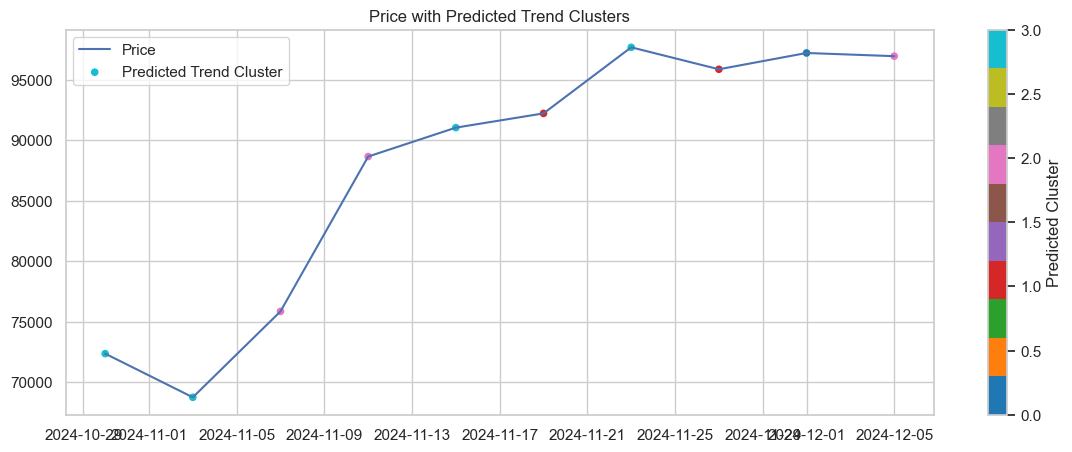

In [27]:
plt.figure(figsize=(14,5))
plt.plot(df_features.loc[y_test.index, 'close'], label='Price')
plt.scatter(df_features.loc[y_test.index].index, df_features.loc[y_test.index, 'close'], 
            c=df_features.loc[y_test.index, 'predicted_cluster'], cmap='tab10', s=20, label='Predicted Trend Cluster')
plt.colorbar(label='Predicted Cluster')
plt.title('Price with Predicted Trend Clusters')
plt.legend()
plt.show()


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create target: next day's cluster
df_features['target_cluster'] = df_features['cluster'].shift(-1)

# Drop last row with NaN target
df_features.dropna(subset=['target_cluster'], inplace=True)

# Features to use (lagged price + hash-rate features)
features = [col for col in df_features.columns if '_lag_' in col]

X = df_features[features]
y = df_features['target_cluster'].astype(int)

# Split train/test without shuffling (80% train)
split_idx = int(len(df_features) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Trend Cluster Prediction Accuracy:", accuracy_score(y_test, y_pred))

# Save predictions to df_features for visualization
df_features.loc[y_test.index, 'predicted_cluster'] = y_pred


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           2       0.40      1.00      0.57         2
           3       0.60      1.00      0.75         3

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.26      0.50      0.34        10

Trend Cluster Prediction Accuracy: 0.5


C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\2073449542.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['target_cluster'] = df_features['cluster'].shift(-1)
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\2073449542.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features.dropna(subset=['target_cluster'], inplace=True)
\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predi

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# For training, use true cluster; for test, use predicted cluster
df_features['cluster_feature_train'] = df_features['cluster']
df_features.loc[y_test.index, 'cluster_feature_train'] = df_features.loc[y_test.index, 'predicted_cluster']

# One-hot encode cluster feature
cluster_dummies = pd.get_dummies(df_features['cluster_feature_train'], prefix='cluster')

# Combine features + cluster dummies
X_reg = pd.concat([df_features[features], cluster_dummies], axis=1)
y_reg = df_features['close'].shift(-1).fillna(method='ffill')  # Predict next day close price

# Align for train/test
X_reg_train = X_reg.iloc[:split_idx]
y_reg_train = y_reg.iloc[:split_idx]
X_reg_test = X_reg.iloc[split_idx:]
y_reg_test = y_reg.iloc[split_idx:]

# Train regression model
reg = LinearRegression()
reg.fit(X_reg_train, y_reg_train)

# Predict price
y_pred_price = reg.predict(X_reg_test)

# Evaluate
mse = mean_squared_error(y_reg_test, y_pred_price)
print(f'Price Prediction MSE with trend feature: {mse:.2f}')

# Save predictions for visualization
df_features.loc[y_reg_test.index, 'predicted_close'] = y_pred_price


Price Prediction MSE with trend feature: 1226908095.28


C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\2372330151.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['cluster_feature_train'] = df_features['cluster']
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\2372330151.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_reg = df_features['close'].shift(-1).fillna(method='ffill')  # Predict next day close price
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\2372330151.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

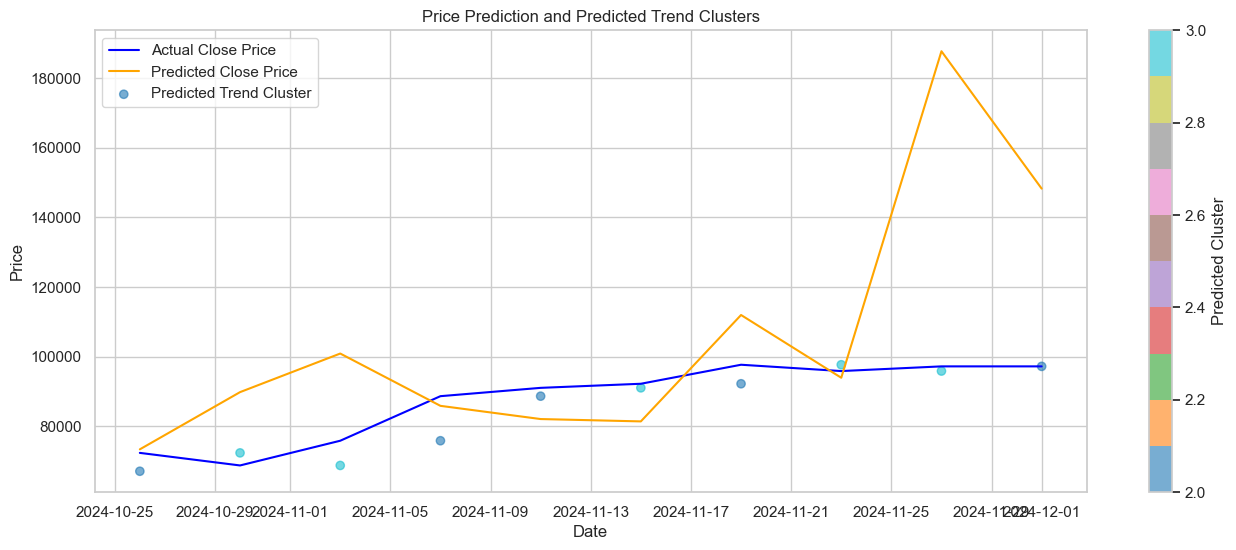

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

# Plot actual and predicted price
plt.plot(df_features.loc[y_reg_test.index].index, y_reg_test, label='Actual Close Price', color='blue')
plt.plot(df_features.loc[y_reg_test.index].index, y_pred_price, label='Predicted Close Price', color='orange')

# Plot predicted trend clusters as colored dots (scatter)
scatter = plt.scatter(
    df_features.loc[y_test.index].index,
    df_features.loc[y_test.index, 'close'],
    c=df_features.loc[y_test.index, 'predicted_cluster'],
    cmap='tab10', label='Predicted Trend Cluster', alpha=0.6
)

plt.colorbar(scatter, label='Predicted Cluster')
plt.title('Price Prediction and Predicted Trend Clusters')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

clf = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(clf, param_dist, n_iter=20, cv=3, verbose=2, n_jobs=-1)
search.fit(X_train, y_train)
print(search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
21 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jl

{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [33]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 4.2 MB/s eta 0:00:36
   ---------------------------------------- 1.0/150.0 MB 2.4 MB/s eta 0:01:03
   ---------------------------------------- 1.3/150.0 MB 2.3 MB/s eta 0:01:05
   ---------------------------------------- 1.8/150.0 MB 2.5 MB/s eta 0:01:01
    --------------------------------------- 2.4/150.0 MB 2.3 MB/s eta 0:01:04
    --------------------------------------- 2.6/150.0 MB 2.2 MB/s eta 0:01:08
    --------------------------------------- 2.9/150.0 MB 2.2 MB/s eta 0:01:06
    --------------------------------------- 3.7/150.0 MB 2.2 MB/s eta 0:01:08
   - -------------------------------------- 4.2/150.0 MB 2.2 MB/s eta 0:01:05
   - -------------------------------------- 5.0/150.0 MB 2.5 MB/s eta 0:01:00
   - -------------------------------------- 5.2/150.0 MB 2.3 MB/s eta 0:01:02
   - -------------------------------------- 5.8/150.0 MB 2.4 MB/s eta 0

In [34]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=len(df_features['cluster'].unique()), random_state=42)
xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))


XGBoost Accuracy: 0.6


In [40]:
# Step 1: Convert to NumPy
X_train_np = X_train.values  # or .to_numpy()

# Step 2: Compute shape params
n_lags = 7
n_features = int(X_train_np.shape[1] / n_lags)

# Step 3: Reshape to 3D for LSTM
X_train_3d = X_train_np.reshape((X_train_np.shape[0], n_lags, n_features))

# Step 4: Build and fit model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, input_shape=(n_lags, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.fit(X_train_3d, y_train, epochs=20, batch_size=32, validation_split=0.1)


Epoch 1/20


\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 488ms/step - loss: 2.6637 - val_loss: 3.1439
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 2.2501 - val_loss: 2.6513
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 1.9468 - val_loss: 2.3260
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 1.6984 - val_loss: 2.0836
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 1.4918 - val_loss: 1.7657
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 1.2939 - val_loss: 1.4389
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 1.1277 - val_loss: 1.1922
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.9824 - val_loss: 1.0948
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8988 - val_loss: 0.8837
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.8450 - val_loss: 0.6367
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.7788 - val_loss: 0.5659
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.7360 - val_loss: 0.4613


In [41]:
import ta

# Example: add RSI and MACD
df_features['rsi'] = ta.momentum.RSIIndicator(df_features['close']).rsi()
df_features['macd'] = ta.trend.MACD(df_features['close']).macd()

# Fill NaNs if any
df_features.fillna(method='bfill', inplace=True)


C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\4045256141.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['rsi'] = ta.momentum.RSIIndicator(df_features['close']).rsi()
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\4045256141.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['macd'] = ta.trend.MACD(df_features['close']).macd()
C:\Users\vasil\AppData\Local\Temp\ipykernel_23624\4045256141.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a 

In [42]:
# Make sure to reshape X_test as well
X_test_np = X_test.values
X_test_3d = X_test_np.reshape((X_test_np.shape[0], n_lags, n_features))

# Predict
y_pred = model.predict(X_test_3d)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


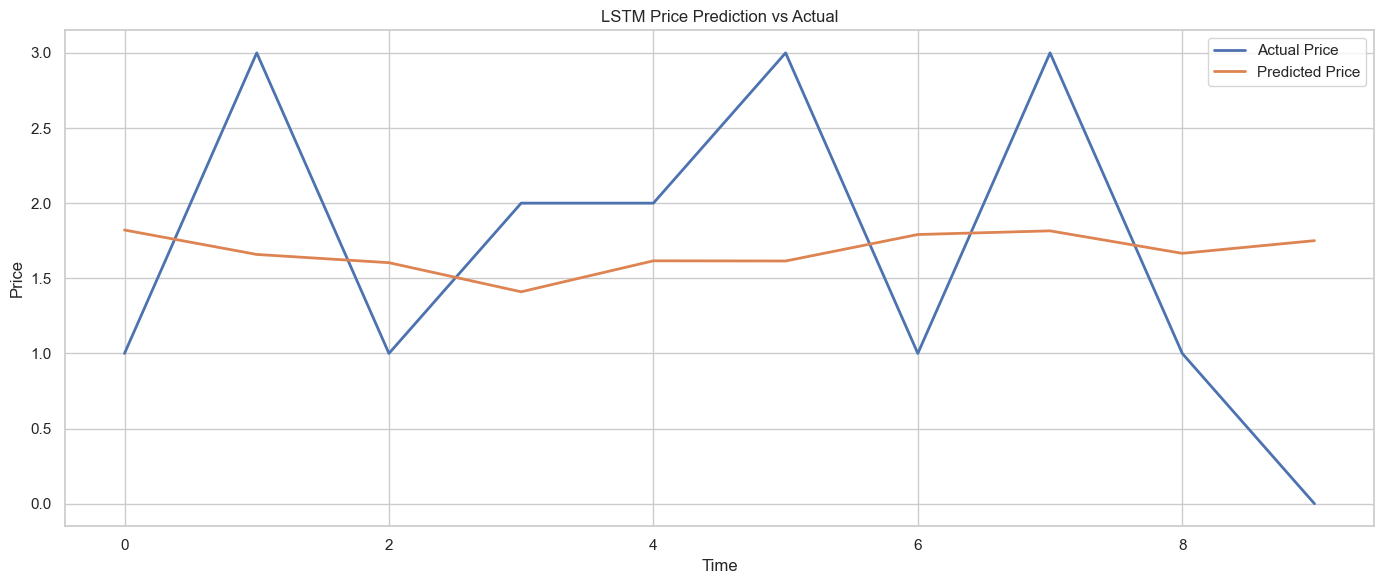

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Price', linewidth=2)
plt.plot(y_pred, label='Predicted Price', linewidth=2)
plt.title('LSTM Price Prediction vs Actual')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


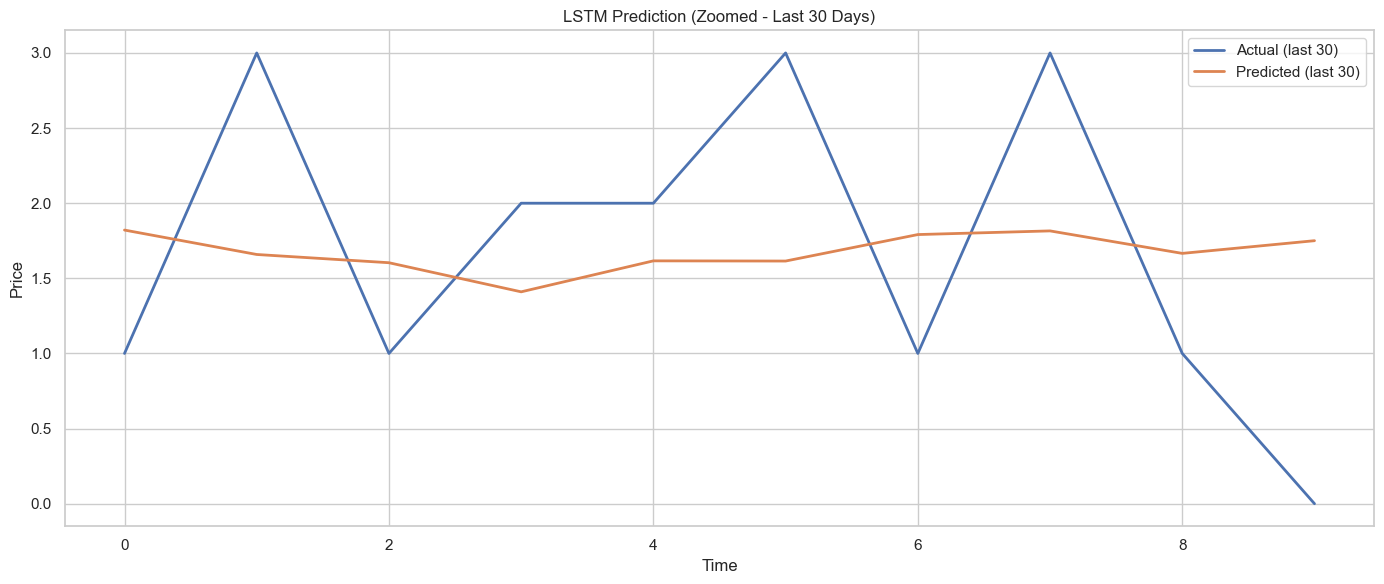

In [44]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-30:], label='Actual (last 30)', linewidth=2)
plt.plot(y_pred[-30:], label='Predicted (last 30)', linewidth=2)
plt.title('LSTM Prediction (Zoomed - Last 30 Days)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


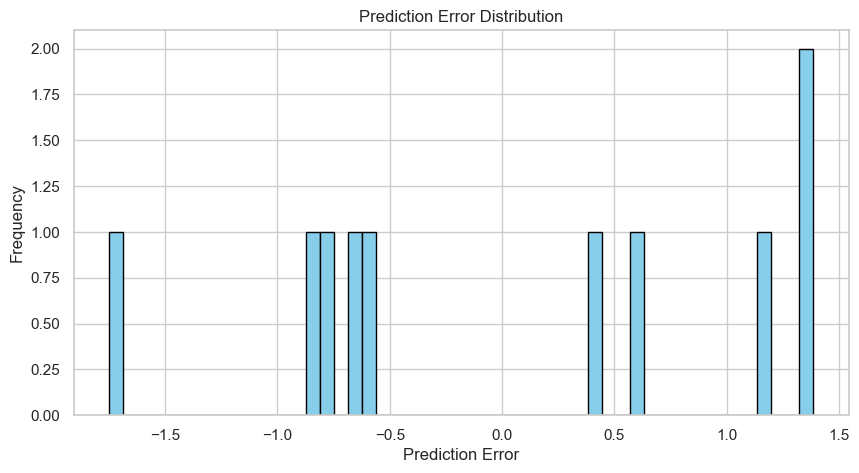

In [45]:
errors = y_test.values - y_pred.flatten()

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
